# 2D forced-dissipative turbulence budgets


A simulation of forced-dissipative two-dimensional turbulence. We solve the
two-dimensional vorticity equation with stochastic excitation and dissipation in
the form of linear drag and hyperviscosity. As a demonstration, we compute how
each of the forcing and dissipation terms contribute to the energy and the
enstrophy budgets.

## Install dependencies

First let's make sure we have all required packages installed.

```julia
using Pkg
pkg"add GeophysicalFlows, Random, Printf, Plots"
```

## Let's begin
Let's load `GeophysicalFlows.jl` and some other needed packages.

In [1]:
using GeophysicalFlows, Random, Printf, Plots
using FourierFlows: parsevalsum

## Choosing a device: CPU or GPU

In [2]:
dev = CPU()     # Device (CPU/GPU)
nothing # hide

## Numerical, domain, and simulation parameters

First, we pick some numerical and physical parameters for our model.

In [3]:
 n, L  = 256, 2π              # grid resolution and domain length
 ν, nν = 2e-7, 2              # hyperviscosity coefficient and hyperviscosity order
 μ, nμ = 1e-1, 0              # linear drag coefficient
dt, tf = 0.005, 0.2 / μ       # timestep and final time
    nt = round(Int, tf / dt)  # total timesteps
    ns = 4                    # how many intermediate times we want to plot
nothing # hide

## Forcing

We force the vorticity equation with stochastic excitation that is delta-correlated in time
and while spatially homogeneously and isotropically correlated. The forcing has a spectrum
with power in a ring in wavenumber space of radius ``k_f`` (`forcing_wavenumber`) and width
``δ_f`` (`forcing_bandwidth`), and it injects energy per unit area and per unit time
equal to ``\varepsilon``. That is, the forcing covariance spectrum is proportional to
``\exp{[-(|\bm{k}| - k_f)^2 / (2 δ_f^2)]}``.

In [4]:
forcing_wavenumber = 14.0 * 2π/L  # the forcing wavenumber, `k_f`, for a spectrum that is a ring in wavenumber space
forcing_bandwidth  = 1.5  * 2π/L  # the width of the forcing spectrum, `δ_f`
ε = 0.1                           # energy input rate by the forcing

grid = TwoDGrid(dev, n, L)

K = @. sqrt(grid.Krsq)             # a 2D array with the total wavenumber

forcing_spectrum = @. exp(-(K - forcing_wavenumber)^2 / (2 * forcing_bandwidth^2))
ε0 = parsevalsum(forcing_spectrum .* grid.invKrsq / 2, grid) / (grid.Lx * grid.Ly)
@. forcing_spectrum *= ε/ε0        # normalize forcing to inject energy at rate ε
nothing # hide

We reset of the random number generator for reproducibility

In [5]:
if dev==CPU(); Random.seed!(1234); else; CUDA.seed!(1234); end
nothing # hide

Next we construct function `calcF!` that computes a forcing realization every timestep.
First we make sure that if `dev=GPU()`, then `CUDA.rand()` function is called for random
numbers uniformly distributed between 0 and 1.

In [6]:
random_uniform = dev==CPU() ? rand : CUDA.rand

function calcF!(Fh, sol, t, clock, vars, params, grid)
  Fh .= sqrt.(forcing_spectrum) .* exp.(2π * im * random_uniform(eltype(grid), size(sol))) ./ sqrt(clock.dt)

  @CUDA.allowscalar Fh[1, 1] = 0 # make sure forcing has zero domain-average

  return nothing
end
nothing # hide

## Problem setup
We initialize a `Problem` by providing a set of keyword arguments. The
`stepper` keyword defines the time-stepper to be used.

In [7]:
prob = TwoDNavierStokes.Problem(dev; nx=n, Lx=L, ν=ν, nν=nν, μ=μ, nμ=nμ, dt=dt, stepper="ETDRK4",
                                calcF=calcF!, stochastic=true)
nothing # hide

Define some shortcuts for convenience.

In [8]:
sol, clock, vars, params, grid = prob.sol, prob.clock, prob.vars, prob.params, prob.grid

x, y = grid.x, grid.y
nothing # hide

First let's see how a forcing realization looks like. Function `calcF!()` computes
the forcing in Fourier space and saves it into variable `vars.Fh`, so we first need to
go back to physical space.

Note that when plotting, we decorate the variable to be plotted with `Array()` to make sure
it is brought back on the CPU when the variable lives on the GPU.

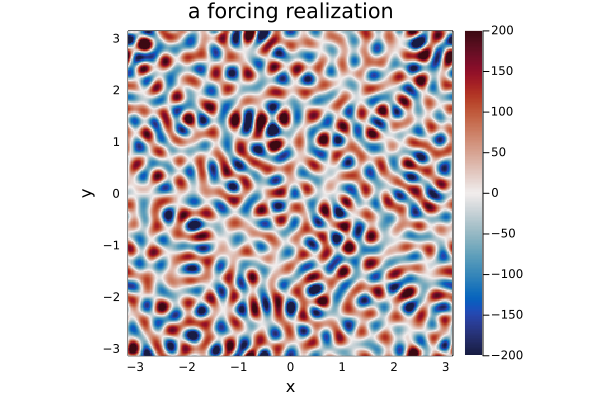

In [9]:
calcF!(vars.Fh, sol, 0.0, clock, vars, params, grid)

heatmap(x, y, Array(irfft(vars.Fh, grid.nx)'),
     aspectratio = 1,
               c = :balance,
            clim = (-200, 200),
           xlims = (-L/2, L/2),
           ylims = (-L/2, L/2),
          xticks = -3:3,
          yticks = -3:3,
          xlabel = "x",
          ylabel = "y",
           title = "a forcing realization",
      framestyle = :box)

## Setting initial conditions

Our initial condition is a fluid at rest.

In [10]:
TwoDNavierStokes.set_ζ!(prob, ArrayType(dev)(zeros(grid.nx, grid.ny)))

## Diagnostics

Create Diagnostics; the diagnostics are aimed to probe the energy and enstrophy budgets.

In [11]:
E  = Diagnostic(TwoDNavierStokes.energy,                               prob, nsteps=nt) # energy
Rᵋ = Diagnostic(TwoDNavierStokes.energy_dissipation_hypoviscosity,     prob, nsteps=nt) # energy dissipation by drag μ
Dᵋ = Diagnostic(TwoDNavierStokes.energy_dissipation_hyperviscosity,    prob, nsteps=nt) # energy dissipation by drag μ
Wᵋ = Diagnostic(TwoDNavierStokes.energy_work,                          prob, nsteps=nt) # energy work input by forcing
Z  = Diagnostic(TwoDNavierStokes.enstrophy,                            prob, nsteps=nt) # enstrophy
Rᶻ = Diagnostic(TwoDNavierStokes.enstrophy_dissipation_hypoviscosity,  prob, nsteps=nt) # enstrophy dissipation by drag μ
Dᶻ = Diagnostic(TwoDNavierStokes.enstrophy_dissipation_hyperviscosity, prob, nsteps=nt) # enstrophy dissipation by drag μ
Wᶻ = Diagnostic(TwoDNavierStokes.enstrophy_work,                       prob, nsteps=nt) # enstrophy work input by forcing
diags = [E, Dᵋ, Wᵋ, Rᵋ, Z, Dᶻ, Wᶻ, Rᶻ] # a list of Diagnostics passed to `stepforward!` will  be updated every timestep.
nothing # hide

## Visualizing the simulation

We define a function that plots the vorticity field and the evolution of
the diagnostics: energy, enstrophy, and all terms involved in the energy and
enstrophy budgets. Last, we also check (by plotting) whether the energy and enstrophy
budgets are accurately computed, e.g., ``\mathrm{d}E/\mathrm{d}t = W^\varepsilon -
R^\varepsilon - D^\varepsilon``.

In [12]:
function computetendencies_and_makeplot(prob, diags)
  sol, clock, vars, params, grid = prob.sol, prob.clock, prob.vars, prob.params, prob.grid

  TwoDNavierStokes.updatevars!(prob)

  E, Dᵋ, Wᵋ, Rᵋ, Z, Dᶻ, Wᶻ, Rᶻ = diags

  clocktime = round(μ * clock.t, digits=2)

  dEdt_numerical = (E[2:E.i] - E[1:E.i-1]) / clock.dt # numerical first-order approximation of energy tendency
  dZdt_numerical = (Z[2:Z.i] - Z[1:Z.i-1]) / clock.dt # numerical first-order approximation of enstrophy tendency

  dEdt_computed = Wᵋ[2:E.i] + Dᵋ[1:E.i-1] + Rᵋ[1:E.i-1]
  dZdt_computed = Wᶻ[2:Z.i] + Dᶻ[1:Z.i-1] + Rᶻ[1:Z.i-1]

  residual_E = dEdt_computed - dEdt_numerical
  residual_Z = dZdt_computed - dZdt_numerical

  εᶻ = parsevalsum(forcing_spectrum / 2, grid) / (grid.Lx * grid.Ly)

  pζ = heatmap(x, y, Array(vars.ζ'),
            aspectratio = 1,
            legend = false,
                 c = :viridis,
              clim = (-25, 25),
             xlims = (-L/2, L/2),
             ylims = (-L/2, L/2),
            xticks = -3:3,
            yticks = -3:3,
            xlabel = "μt",
            ylabel = "y",
             title = "∇²ψ(x, y, μt=" * @sprintf("%.2f", μ * clock.t) * ")",
        framestyle = :box)

  pζ = plot(pζ, size = (400, 400))

  t = E.t[2:E.i]

  p1E = plot(μ * t, [Wᵋ[2:E.i] ε.+0*t Dᵋ[1:E.i-1] Rᵋ[1:E.i-1]],
             label = ["energy work, Wᵋ" "ensemble mean energy work, <Wᵋ>" "dissipation, Dᵋ" "drag, Rᵋ = - 2μE"],
         linestyle = [:solid :dash :solid :solid],
         linewidth = 2,
             alpha = 0.8,
            xlabel = "μt",
            ylabel = "energy sources and sinks")

  p2E = plot(μ * t, [dEdt_computed, dEdt_numerical],
           label = ["computed Wᵋ-Dᵋ" "numerical dE/dt"],
       linestyle = [:solid :dashdotdot],
       linewidth = 2,
           alpha = 0.8,
          xlabel = "μt",
          ylabel = "dE/dt")

  p3E = plot(μ * t, residual_E,
           label = "residual dE/dt = computed - numerical",
       linewidth = 2,
           alpha = 0.7,
          xlabel = "μt")

  t = Z.t[2:E.i]

  p1Z = plot(μ * t, [Wᶻ[2:Z.i] εᶻ.+0*t Dᶻ[1:Z.i-1] Rᶻ[1:Z.i-1]],
           label = ["enstrophy work, Wᶻ" "mean enstrophy work, <Wᶻ>" "enstrophy dissipation, Dᶻ" "enstrophy drag, Rᶻ = - 2μZ"],
       linestyle = [:solid :dash :solid :solid],
       linewidth = 2,
           alpha = 0.8,
          xlabel = "μt",
          ylabel = "enstrophy sources and sinks")


  p2Z = plot(μ * t, [dZdt_computed, dZdt_numerical],
         label = ["computed Wᶻ-Dᶻ" "numerical dZ/dt"],
     linestyle = [:solid :dashdotdot],
     linewidth = 2,
         alpha = 0.8,
        xlabel = "μt",
        ylabel = "dZ/dt")

  p3Z = plot(μ * t, residual_Z,
         label = "residual dZ/dt = computed - numerical",
     linewidth = 2,
         alpha = 0.7,
        xlabel = "μt")

  layout = @layout Plots.grid(3, 2)

  pbudgets = plot(p1E, p1Z, p2E, p2Z, p3E, p3Z, layout=layout, size = (900, 1200))

  return pζ, pbudgets
end
nothing # hide

## Time-stepping the `Problem` forward

Finally, we time-step the `Problem` forward in time.

In [13]:
startwalltime = time()
for i = 1:ns
  stepforward!(prob, diags, round(Int, nt/ns))

  TwoDNavierStokes.updatevars!(prob)

  cfl = clock.dt * maximum([maximum(vars.u) / grid.dx, maximum(vars.v) / grid.dy])

  log = @sprintf("step: %04d, t: %.1f, cfl: %.3f, walltime: %.2f min", clock.step, clock.t,
        cfl, (time()-startwalltime)/60)

  println(log)
end

step: 0100, t: 0.5, cfl: 0.158, walltime: 0.02 min
step: 0200, t: 1.0, cfl: 0.245, walltime: 0.04 min
step: 0300, t: 1.5, cfl: 0.284, walltime: 0.06 min
step: 0400, t: 2.0, cfl: 0.285, walltime: 0.08 min


## Plot
And now let's see what we got. First we plot the final snapshot
of the vorticity field.

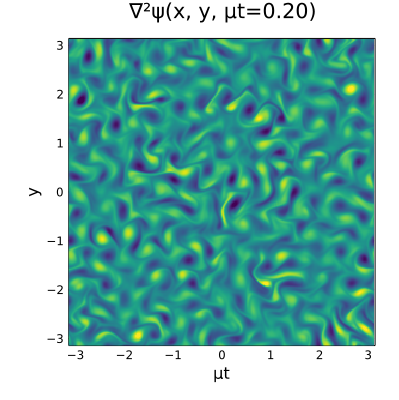

In [14]:
pζ, pbudgets = computetendencies_and_makeplot(prob, diags)

pζ

And finaly the energy and enstrophy budgets.

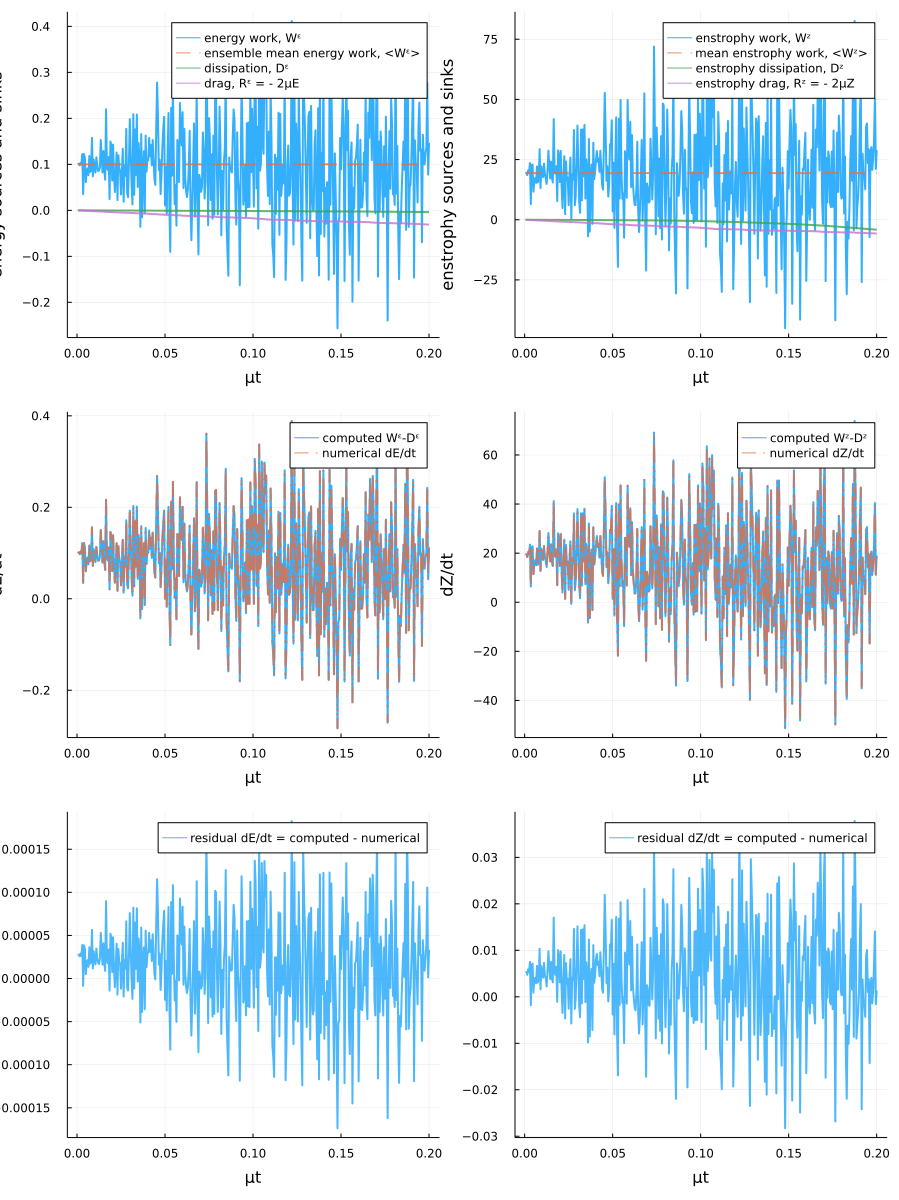

In [15]:
pbudgets

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*